# When Does a City Shine Brightest?

**Nighttime lights over Seville and the Andalusian coast**

Every other tutorial in this book measures sunlight bouncing off the Earth. This one
measures light the Earth emits on its own, at night, which is almost entirely a measure
of people: streets, ports, greenhouses, industry, and the nights a city decides to
celebrate something.

The question here is not *how much* light there is — that map is well known and boring,
the cities are bright and the countryside is dark — but **when**. Which night of the year
does each pixel of a city reach its maximum? `get_peak_period()` answers that for any
index and any dataset, and nighttime lights are where the answer can be checked against
something we already know: Seville's Feria has a date.

The notebook does two things:

1. **The night of the peak**, with the daily product over Seville in 2017 — and a hard
   look at how much of that map is signal and how much is moonlight, clouds and luck.
2. **Forty years of coastal growth**, joining DMSP-OLS (1992-2013) to VIIRS (2014-) along
   the Andalusian coast, and being honest about what can and cannot be compared across
   that seam.

The method of the first part is the one in [Ramírez et al.
(2023)](https://doi.org/10.1002/pan3.10520), which mapped the month of peak radiance for
every urban pixel on Earth and found that it moves with the calendar of each country's
festivities.

## 1. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='geemap.conversion')

import datetime as dt

import ee
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from urllib.request import urlopen
from PIL import Image
from io import BytesIO

from ndvi2gif import NdviSeasonality

# ee.Authenticate()          # only the first time
ee.Initialize(project='your-project-id')
print('✓ Earth Engine initialised')

✓ Earth Engine initialised


*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


## 2. Three datasets, one signal

ndvi2gif exposes the night in three flavours, and the choice decides what questions can
be asked:

| `sat=` | Collection | Cadence | Span | Resolution |
|---|---|---|---|---|
| `'VIIRS'` | `NOAA/VIIRS/DNB/MONTHLY_V1/VCMSLCFG` | monthly | 2014- | ~500 m |
| `'VIIRS_DAILY'` | `NASA/VIIRS/002/VNP46A2` | daily | 2012- | ~500 m |
| `'DMSP'` | `NOAA/DMSP-OLS/NIGHTTIME_LIGHTS` | annual | 1992-2013 | ~1 km |

The daily one is the Black Marble product, and the difference is not only cadence: it
models away moonlight, atmospheric scattering, terrain and viewing angle, so one night
can be compared with the next. That is what makes a *date* of maximum meaningful instead
of merely arithmetic. With `cloud_filter=True` (the default) ndvi2gif also applies the
product's own quality flag, keeping the retrievals graded as good and dropping the rest.

The monthly product is what the paper used, and it is cheaper: one image per month
instead of thirty.

In [2]:
# Central Seville: the historic centre, the river and the Feria grounds
SEVILLE = ee.Geometry.Rectangle([-6.02, 37.35, -5.93, 37.42])

daily = NdviSeasonality(roi=SEVILLE, sat='VIIRS_DAILY', index='ntl', key='mean',
                        periods=365, start_year=2017, end_year=2017)

print('periods:', daily.periods)
print('first period:', daily._period_date_range(2017, 0))
print('last period: ', daily._period_date_range(2017, 364))

There we go again...
VIIRS Black Marble daily nighttime lights (2012-present, ~500m resolution)
Applying pixel-level quality mask using Mandatory_Quality_Flag
periods: 365
first period: ('2017-01-01', '2017-01-02')
last period:  ('2017-12-31', '2018-01-01')


`periods=365` splits the year into single days. Any number works — 4 seasons, 12 months,
24 fortnights, 73 pentads — and `get_peak_period()` returns the index of the period that
holds the maximum, so the unit of the answer is whatever the periods are.

## 3. The night of the peak

`get_peak_period()` builds one candidate per period and lets `qualityMosaic` pick the
winner, so periods with no valid retrieval simply do not compete. Three arguments matter
here:

- `mask_below=` drops pixels whose peak never reaches a threshold. The date of maximum of
  an unlit field is the date its noise happened to be highest, which is nothing at all.
- `return_peak_value=True` keeps the radiance at the peak, to judge whether the maximum
  stands out or is one of many similar nights.
- `return_ties=True` counts how many periods reach that same maximum. The library does
  not invent a winner when several tie — it says so, and lets you decide.

In [3]:
peak = daily.get_peak_period(mask_below=5, return_peak_value=True, return_ties=True)
peak.bandNames().getInfo()

Year 2017: 365/365 periods with data using ntl index


['peak_period', 'peak_value', 'ties']

In [4]:
def peak_dates(image, roi, year=2017, scale=500, top=12):
    """Most frequent peak days inside an ROI, as real dates."""
    # eq() at the native scale: a frequency histogram of a composite without a
    # fixed projection invents fractional counts for values no pixel holds
    doys = image.select('peak_period').reduceRegion(
        ee.Reducer.frequencyHistogram(), roi, scale, maxPixels=1e9
    ).getInfo()['peak_period']
    rows = [(int(float(d)), n) for d, n in doys.items()]
    rows.sort(key=lambda r: -r[1])
    jan1 = dt.date(year, 1, 1)
    return pd.DataFrame(
        [{'day of year': d,
          'date': jan1 + dt.timedelta(days=d - 1),
          'pixels': round(n)} for d, n in rows[:top]]
    ).set_index('day of year')

peak_dates(peak, SEVILLE)

,date,pixels
day of year,,
81,2017-03-22,38
123,2017-05-03,15
139,2017-05-19,13
341,2017-12-07,12
150,2017-05-30,9
96,2017-04-06,9
126,2017-05-06,8
129,2017-05-09,8
149,2017-05-29,7


The single most common peak night of 2017 is **22 March**, which celebrates nothing at
all. The Feria de Abril — 30 April to 6 May that year — is in the list too, on 3 and 6
May, but below it.

That is the honest first result, and it is the reason the next two sections exist. With
365 candidate nights and a few hundred pixels, *something* has to come first, and a table
of counts cannot tell an event from an accident.

### How much of this is real?

Two checks before believing any of it.

**The ties.** With 365 periods and a continuous radiance, exact ties should be rare. If
they are not, the peak is being decided by rounding rather than by the city.

**The number of good nights.** A pixel's maximum is drawn from however many nights
survived the quality mask. A month with ten valid nights and a month with twenty-eight
are not equally likely to hold the annual maximum: the larger sample wins more often on
average, but the *smaller* one is more volatile, and a single cloudy-edge night can beat
a whole quiet month.

In [5]:
stats = peak.select('ties').reduceRegion(
    ee.Reducer.frequencyHistogram(), SEVILLE, 500, maxPixels=1e9
).getInfo()['ties']
print('pixels by number of tied nights:',
      {int(float(k)): round(v) for k, v in sorted(stats.items())})

# Valid nights per month, from the quality flag itself
quality = NdviSeasonality(roi=SEVILLE, sat='VIIRS_DAILY', index='quality_flag',
                          key='count', periods=12, start_year=2017, end_year=2017)
nights = ee.Image(quality.get_year_composite().first()).reduceRegion(
    ee.Reducer.max(), SEVILLE, 500, maxPixels=1e9).getInfo()
pd.Series({m: int(n) for m, n in nights.items()},
          index=quality.period_names, name='valid nights').to_frame().T

pixels by number of tied nights: {1: 310}
There we go again...
VIIRS Black Marble daily nighttime lights (2012-present, ~500m resolution)
Applying pixel-level quality mask using Mandatory_Quality_Flag


Year 2017: 12/12 periods with data using quality_flag index


,january,february,march,april,may,june,july,august,september,october,november,december
valid nights,28,17,24,24,28,27,30,28,29,27,26,25


Two readings.

**No ties.** All 310 lit pixels have a single winning night. Radiance is a continuous
measurement, so exact ties are almost impossible — unlike an integer count, where they
are routine. The `ties` band matters elsewhere; here it confirms there is nothing to
worry about.

**The nights are not evenly spread.** February keeps 17 valid nights against 30 in July:
the quality mask removes the cloudy half of a wet winter month. That asymmetry does not
bias the date of the maximum by itself, but it does mean the winter nights that survive
are the unusually clear ones — and a clear, dry, moonless night is exactly when a city
looks brightest from orbit without having changed at all.

## 4. Does the Feria show up?

Seville's Feria de Abril ran from **30 April to 6 May 2017**, and Semana Santa from **9
to 16 April**. Both are lit: the Feria grounds carry tens of thousands of bulbs for a
week, and the processions light the centre at night.

The honest test is not whether those dates appear somewhere in the map — with 365 days,
something has to be the maximum — but whether they appear **more than chance would
allow**, and whether they appear **where** they should: the Feria on the Los Remedios
fairground, not scattered over the city.

In [6]:
FERIA = ee.Geometry.Rectangle([-6.005, 37.370, -5.985, 37.383])   # Real de la Feria
CENTRE = ee.Geometry.Rectangle([-6.000, 37.383, -5.980, 37.400])  # historic centre

for name, geom in [('Feria grounds', FERIA), ('Historic centre', CENTRE)]:
    print(f'--- {name}')
    print(peak_dates(peak, geom, top=5).to_string())

--- Feria grounds


                   date  pixels
day of year                    
126          2017-05-06       3
81           2017-03-22       3
123          2017-05-03       2
75           2017-03-16       2
341          2017-12-07       2
--- Historic centre


                   date  pixels
day of year                    
81           2017-03-22       6
75           2017-03-16       2
341          2017-12-07       2
150          2017-05-30       2
16           2017-01-16       1


In [7]:
FERIA = ee.Geometry.Rectangle([-6.005, 37.370, -5.985, 37.383])   # Real de la Feria
CENTRE = ee.Geometry.Rectangle([-6.000, 37.383, -5.980, 37.400])  # historic centre

FERIA_WEEK = (dt.date(2017, 4, 30), dt.date(2017, 5, 6))    # Feria de Abril 2017
HOLY_WEEK = (dt.date(2017, 4, 9), dt.date(2017, 4, 16))     # Semana Santa 2017
MARCH_22 = (dt.date(2017, 3, 22), dt.date(2017, 3, 22))     # the winner, which
                                                            # celebrates nothing

def share_peaking_in(image, roi, window, scale=500):
    """Share of valid pixels whose peak falls inside a date window."""
    band = image.select('peak_period')
    first, last = (d.timetuple().tm_yday for d in window)
    inside = band.gte(first).And(band.lte(last))
    counts = ee.Image.cat(inside.selfMask().rename('inside'),
                          band.mask().selfMask().rename('valid')).reduceRegion(
        ee.Reducer.count(), roi, scale, maxPixels=1e9).getInfo()
    return counts['inside'] / counts['valid'] if counts['valid'] else float('nan')

rows = []
for label, window in [('Feria week (7 nights)', FERIA_WEEK),
                      ('Holy Week (8 nights)', HOLY_WEEK),
                      ('22 March (1 night)', MARCH_22)]:
    nights = (window[1] - window[0]).days + 1
    rows.append({
        'window': label,
        'expected by chance': nights / 365,
        'Feria grounds': share_peaking_in(peak, FERIA, window),
        'Historic centre': share_peaking_in(peak, CENTRE, window),
        'Whole city': share_peaking_in(peak, SEVILLE, window),
    })

pd.DataFrame(rows).set_index('window').style.format('{:.1%}')

,expected by chance,Feria grounds,Historic centre,Whole city
window,,,,
Feria week (7 nights),1.9%,33.3%,0.0%,11.0%
Holy Week (8 nights),2.2%,0.0%,0.0%,4.0%
22 March (1 night),0.3%,26.7%,35.0%,12.7%


Now the two lists differ, and they differ in the right direction. **6 May** — the last
night of the Feria — leads the fairground and is absent from the historic centre. **22
March** leads the centre.

Counting the top dates is still eyeballing, though. The question deserves a number.

## 5. The map

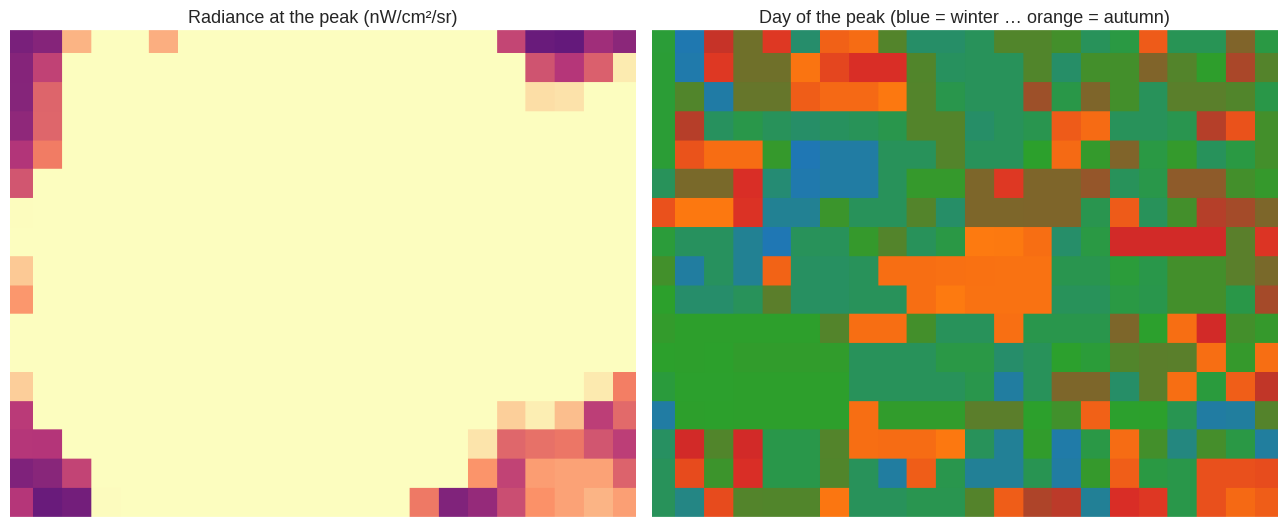

In [8]:
def thumbnail(image, vis, region, dimensions=600):
    url = image.visualize(**vis).getThumbURL(
        {'region': region, 'dimensions': dimensions, 'format': 'png'})
    return np.array(Image.open(BytesIO(urlopen(url).read())))

# Colour by season of the peak, so the pattern is readable at a glance
season_vis = {'min': 1, 'max': 365, 'palette': ['1f77b4', '2ca02c', 'd62728', 'ff7f0e']}
radiance_vis = {'min': 0, 'max': 120, 'palette': ['000004', '51127c', 'b63679',
                                                  'fb8861', 'fcfdbf']}

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
axes[0].imshow(thumbnail(peak.select('peak_value'), radiance_vis, SEVILLE))
axes[0].set_title('Radiance at the peak (nW/cm²/sr)')
axes[1].imshow(thumbnail(peak.select('peak_period'), season_vis, SEVILLE))
axes[1].set_title('Day of the peak (blue = winter … orange = autumn)')
for ax in axes:
    ax.axis('off')
plt.tight_layout()

The radiance map is the expected one: the bridges, the main avenues and the industrial
estates. The timing map is not — it has structure. Blocks of pixels share a peak night,
which is what a real event looks like: a fairground lights up as a unit, a street does
not light up pixel by pixel.

## 6. Monthly instead of daily

The same question at the resolution of the paper: which **month** does each pixel peak
in? Cheaper, less noisy, and the unit most studies use. The only change is `periods=12`
and the monthly collection.

In [9]:
monthly = NdviSeasonality(roi=SEVILLE, sat='VIIRS', index='avg_rad', key='mean',
                          periods=12, start_year=2014, end_year=2023)

peak_month = monthly.get_peak_period(mask_below=5, return_ties=True)

hist = peak_month.select('peak_period').reduceRegion(
    ee.Reducer.frequencyHistogram(), SEVILLE, 500, maxPixels=1e9
).getInfo()['peak_period']
months = pd.Series({monthly.period_names[int(float(k)) - 1]: round(v)
                    for k, v in hist.items()}, name='pixels')
months.reindex(monthly.period_names).fillna(0).astype(int).to_frame().T

There we go again...
VIIRS DNB monthly nighttime lights (2014-present, ~500m resolution)


Year 2014: 12/12 periods with data using avg_rad index


Year 2015: 12/12 periods with data using avg_rad index


Year 2016: 12/12 periods with data using avg_rad index


Year 2017: 12/12 periods with data using avg_rad index


...

Year 2020: 12/12 periods with data using avg_rad index


Year 2021: 12/12 periods with data using avg_rad index


Year 2022: 12/12 periods with data using avg_rad index


Year 2023: 12/12 periods with data using avg_rad index


,january,february,march,april,may,june,july,august,september,october,november,december
pixels,10,20,65,48,45,69,14,14,7,1,5,13


At monthly resolution and averaged over ten years, the peak spreads across **March, June,
April and May** — spring and early summer — with October almost empty.

This is the shape the paper works with, and it is worth understanding why it is not
"December, because of Christmas lights". The DNB sees the total radiance leaving the
surface, which depends on how clear the sky was, how much of the light is scattered back,
and how long the night is. In a Mediterranean spring the air is dry and clean and the
city is bright; in an Atlantic December it is humid and often overcast. A festivity has
to be big enough to beat that seasonal background — and the Feria, concentrated in one
neighbourhood for one week, is exactly the kind of signal that survives it *locally* and
disappears when the whole city is averaged.

## 7. Forty years of coast

The second half of the notebook changes the question from *when* to *how much*, and the
area from a city to the Andalusian coast — the strip that went from fishing villages to
a continuous line of towns, greenhouses and resorts.

No single sensor covers it. DMSP-OLS runs 1992-2013 and VIIRS from 2014, so the series
has a seam in the middle, and the two sides are **not** the same measurement:

- DMSP is a **6-bit digital number** (0-63) that saturates over city centres, with no
  calibration between satellites or years.
- VIIRS is a **calibrated radiance** in nW/cm²/sr with no saturation in practice.

Converting one into the other is a research problem of its own. What can be done honestly
is to read each side on its own terms and compare *patterns*, not values.

In [10]:
COAST = ee.Geometry.Rectangle([-7.5, 36.0, -1.6, 37.3])

dmsp = NdviSeasonality(roi=COAST, sat='DMSP', index='stable_lights', key='mean',
                       periods=1, start_year=1992, end_year=2013)
dmsp_years = dmsp.get_year_composite()

viirs = NdviSeasonality(roi=COAST, sat='VIIRS', index='avg_rad', key='median',
                        periods=1, start_year=2014, end_year=2025)
viirs_years = viirs.get_year_composite()

print('DMSP years: ', dmsp_years.size().getInfo())
print('VIIRS years:', viirs_years.size().getInfo())

There we go again...
DMSP-OLS annual nighttime lights (1992-2013, ~1km resolution)


Year 1992: 1/1 periods with data using stable_lights index


Year 1993: 1/1 periods with data using stable_lights index


Year 1994: 1/1 periods with data using stable_lights index


Year 1995: 1/1 periods with data using stable_lights index


...

Year 2023: 1/1 periods with data using avg_rad index


Year 2024: 1/1 periods with data using avg_rad index


Year 2025: 1/1 periods with data using avg_rad index


DMSP years:  22


VIIRS years: 12


`periods=1` makes each year a single composite, which is the only thing DMSP supports —
it has one image per year, so there is nothing to resolve within it. The years then *are*
the series.

In [11]:
def lit_area(collection, threshold, years, scale=1000):
    """Square kilometres above a brightness threshold, year by year."""
    rows = []
    images = collection.toList(collection.size())
    for i, year in enumerate(years):
        image = ee.Image(images.get(i)).select(0)
        area = (image.gte(threshold).selfMask()
                .multiply(ee.Image.pixelArea()).divide(1e6)
                .reduceRegion(ee.Reducer.sum(), COAST, scale, maxPixels=1e9)
                .getInfo())
        rows.append({'year': year, 'km2': list(area.values())[0] or 0})
    return pd.DataFrame(rows).set_index('year')['km2']

# Thresholds are not equivalent: 20 DN of DMSP and 5 nW/cm2/sr of VIIRS are
# both "clearly a town", but they are different quantities
dmsp_lit = lit_area(dmsp_years, 20, range(1992, 2014))
viirs_lit = lit_area(viirs_years, 5, range(2014, 2026), scale=500)

summary = pd.DataFrame({
    'first year': [dmsp_lit.index[0], viirs_lit.index[0]],
    'first km²': [dmsp_lit.iloc[0], viirs_lit.iloc[0]],
    'last year': [dmsp_lit.index[-1], viirs_lit.index[-1]],
    'last km²': [dmsp_lit.iloc[-1], viirs_lit.iloc[-1]],
}, index=['DMSP-OLS', 'VIIRS'])
summary['growth'] = summary['last km²'] / summary['first km²'] - 1
print(summary.round(1).to_string())

          first year  first km²  last year  last km²  growth
DMSP-OLS        1992     4207.9       2013    7887.9     0.9
VIIRS           2014     2908.6       2025    3182.6     0.1


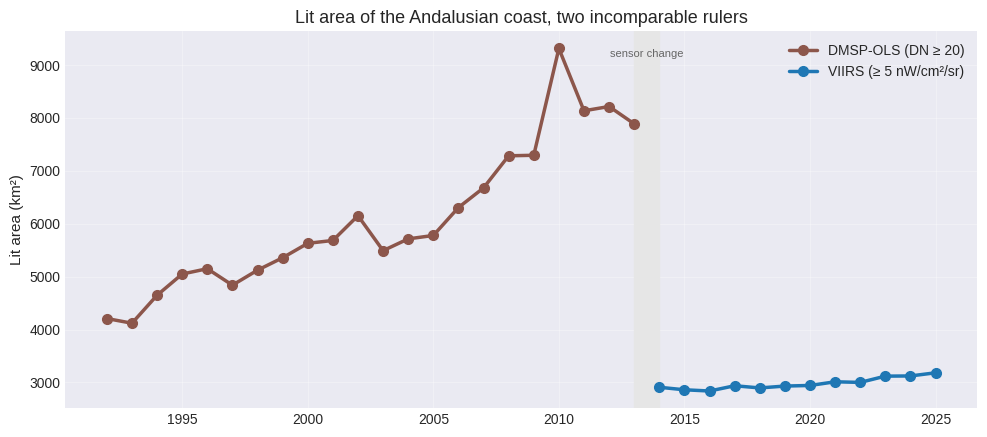

In [12]:
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(dmsp_lit.index, dmsp_lit.values, 'o-', color='#8c564b', label='DMSP-OLS (DN ≥ 20)')
ax.plot(viirs_lit.index, viirs_lit.values, 'o-', color='#1f77b4',
        label='VIIRS (≥ 5 nW/cm²/sr)')
ax.axvspan(2013, 2014, color='0.9')
ax.text(2013.5, ax.get_ylim()[1] * 0.95, 'sensor change', ha='center', fontsize=8,
        color='0.4')
ax.set_ylabel('Lit area (km²)')
ax.set_title('Lit area of the Andalusian coast, two incomparable rulers')
ax.legend(frameon=False)
for side in ('top', 'right'):
    ax.spines[side].set_visible(False)
plt.tight_layout()

Two ascending lines that must not be joined into one. The lit area runs from 4,208 km² in
1992 to 7,888 km² in 2013 on DMSP (+90%), and from 2,909 km² in 2014 to 3,183 km² in 2025
on VIIRS (+9%). The drop of five thousand square kilometres at the seam is the change of
instrument, not a blackout: `DN ≥ 20` and `≥ 5 nW/cm²/sr` are two different definitions of
"lit", and DMSP's coarse optics smear a town's light over neighbouring kilometres, which
inflates any area measured from it.

Even the +90% is not all construction. DMSP was flown by a succession of satellites whose
digital numbers were never calibrated against each other, so part of that slope is the
instrument drifting. Published DMSP time series apply an intercalibration — a per-year
regression against a reference scene — before reading any trend, and this notebook
deliberately does not: the point here is the shape of the two records and where they can
and cannot be joined.

What survives all those caveats is the direction, which both halves agree on and which
the maps below show directly: the coast filled in, fastest during the building boom of
the DMSP years.

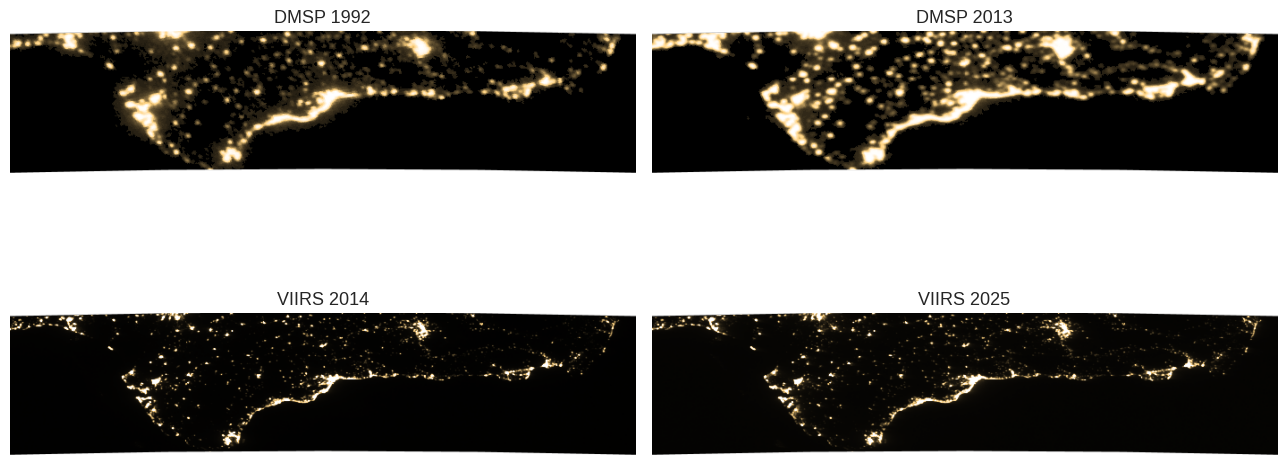

In [13]:
lights_vis_dmsp = {'min': 0, 'max': 63, 'palette': ['000000', 'ffd27f', 'ffffff']}
lights_vis_viirs = {'min': 0, 'max': 40, 'palette': ['000000', 'ffd27f', 'ffffff']}

fig, axes = plt.subplots(2, 2, figsize=(13, 7))
pairs = [(ee.Image(dmsp_years.toList(30).get(0)), lights_vis_dmsp, 'DMSP 1992'),
         (ee.Image(dmsp_years.toList(30).get(21)), lights_vis_dmsp, 'DMSP 2013'),
         (ee.Image(viirs_years.toList(30).get(0)), lights_vis_viirs, 'VIIRS 2014'),
         (ee.Image(viirs_years.toList(30).get(11)), lights_vis_viirs, 'VIIRS 2025')]
for ax, (image, vis, title) in zip(axes.ravel(), pairs):
    ax.imshow(thumbnail(image.select(0), vis, COAST, dimensions=700))
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()

The four maps are the same coast through two instruments. Between 1992 and 2013 the
change is unmistakable: the Costa del Sol becomes a continuous ribbon of light from
Málaga to Estepona, and the greenhouse sea around El Ejido appears out of the dark.

Note what DMSP does to a city centre: it saturates. Málaga and Seville are flat white
blobs in 1992 and flat white blobs in 2013, so the growth that the map shows is growth at
the **edges**, where the sensor still has range. VIIRS, with no saturation, resolves the
structure inside the cities — which is another reason the two halves of the record cannot
be compared value by value.

## 8. What to take away

**A local peak is an event; a shared peak is the atmosphere.** The Feria week holds the
maximum of a third of the fairground's pixels and of none of the historic centre's. A
single night in March holds the maximum of a quarter of the fairground *and* a third of
the centre. The first is a fair; the second is a clear night. Nothing but the spatial
pattern separates them, which is why `get_peak_period()` returns a map and not a date.

**Ask the question where the answer can be local.** Averaged over the whole city, the
Feria is invisible: the monthly map peaks in spring because springs are clear, not
because anything happened. The signal exists at the scale of the event.

**Not every celebration is a light.** Holy Week, which fills the same city for a week, is
indistinguishable from chance. Processions are lit at street level, under cover and often
by candle: the sensor is looking straight down at rooftops.

**Ties and coverage are part of the answer.** `return_ties=True` and a count of valid
observations per period cost one line each and tell you whether the map is reporting a
measurement or rounding noise.

**Two records are not one record.** DMSP and VIIRS both measure nighttime light, and the
seam between them cannot be crossed by rescaling a threshold. Read each on its own terms,
compare patterns rather than values, and say so in the caption.